<a href="https://colab.research.google.com/github/sardar-ammad-143/Basic-Python/blob/main/measurement_summary_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
print("Test-One Start")

Test-One Start


In [4]:
# Load the dataset from the sample_data directory
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Replace 'your_dataset.csv' with the actual name of your uploaded file
data = pd.read_csv('/content/sample_data/Measurement_summary preprocessed .csv')

print("Dataset Uploaded")

Dataset Uploaded


In [5]:
# Get the number of instances (rows) and attributes (columns)
num_instances = data.shape[0]  # Number of rows
num_attributes = data.shape[1]  # Number of columns

# Print the results
print(f'Total number of instances (rows): {num_instances}')
print(f'Total number of attributes (columns): {num_attributes}')

# Get the data types of the columns
data_types = data.dtypes

# Print the data types
print(data_types)

Total number of instances (rows): 647511
Total number of attributes (columns): 6
SO2      float64
NO2      float64
O3       float64
CO       float64
PM10       int64
PM2.5      int64
dtype: object


In [6]:
# Summary statistics for numerical columns
summary_statistics = data.describe()
print(summary_statistics)

                 SO2            NO2             O3             CO  \
count  647511.000000  647511.000000  647511.000000  647511.000000   
mean       -0.001795       0.022519       0.017979       0.509197   
std         0.078832       0.115153       0.099308       0.405319   
min        -1.000000      -1.000000      -1.000000      -1.000000   
25%         0.003000       0.016000       0.008000       0.300000   
50%         0.004000       0.025000       0.021000       0.500000   
75%         0.005000       0.038000       0.034000       0.600000   
max         3.736000      38.445000      33.600000      71.700000   

                PM10          PM2.5  
count  647511.000000  647511.000000  
mean       43.708051      25.411995  
std        71.137342      43.924595  
min        -1.000000      -1.000000  
25%        22.000000      11.000000  
50%        35.000000      19.000000  
75%        53.000000      31.000000  
max      3586.000000    6256.000000  


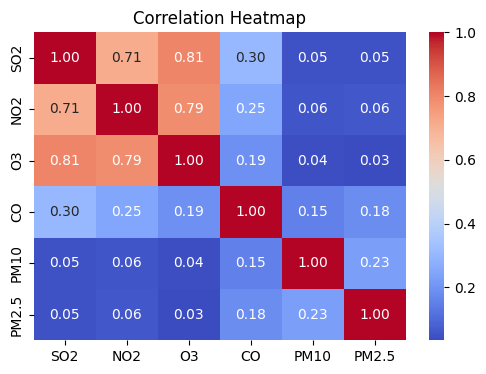

In [7]:
# Calculate the correlation matrix
correlation_matrix = data.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [8]:
pip install scikit-learn

In [9]:
from sklearn.model_selection import train_test_split
# Split the dataset into 70% training and 30% testing
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Display the sizes of the training and testing sets
print(f'Training set size: {len(train_data)}')
print(f'Testing set size: {len(test_data)}')

Training set size: 518008
Testing set size: 129503


In [10]:
pip install tensorflow

In [11]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
# Print the column names to identify the target variable
print("Column names in the dataset:")
print(data.columns)
# print(data.head())


Column names in the dataset:
Index(['SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2.5'], dtype='object')


In [14]:
# Assume 'target' is the column we want to predict
target_variable = 'PM10'  # Change this to your actual target column name
X = data.drop(target_variable, axis=1)  # Features
y = data[target_variable]                # Target variable

In [15]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define a ColumnTransformer to handle different types of features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Normalize numeric features
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # One-hot encode categorical features
    ]
)

# Create a preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Preprocess the data
X_processed = pipeline.fit_transform(X)


# Split the processed data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42)


# Check the shape of the training data
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


Shape of X_train: (453257, 5)
Shape of y_train: (453257,)


In [16]:
# Build the Neural Network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='sigmoid', input_shape=(X_train.shape[1],)),  # Input layer with 128 neurons
    tf.keras.layers.Dense(128, activation='sigmoid'),                                   # First hidden layer with 64 neurons
    tf.keras.layers.Dense(128, activation='sigmoid'),                                   # Second hidden layer with 64 neurons
    tf.keras.layers.Dense(128, activation='sigmoid'),                                   # Third hidden layer with 64 neurons
    tf.keras.layers.Dense(1, activation='sigmoid')                                  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model using validation_data
model.fit(X_train, y_train, epochs=3, batch_size=32, validation_data=(X_test, y_test))

# Make predictions on the test set
y_test_pred = (model.predict(X_test) > 0.5).astype("int32")

# Make predictions on the test set
y_test_pred = (model.predict(X_test) > 0.5).astype("int32")

# Convert y_test and y_test_pred to 1D arrays
y_test = y_test.values.flatten()
y_pred = y_test_pred.flatten()



Epoch 1/3


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14165/14165 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - accuracy: 1.9807e-04 - loss: -12771.7998 - val_accuracy: 1.4929e-04 - val_loss: -53550.1328
Epoch 2/3
14165/14165 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 2.0961e-04 - loss: -69949.6250 - val_accuracy: 1.4929e-04 - val_loss: -123688.4609
Epoch 3/3
14165/14165 ━━━━━━━━━━━━━━━━━━━━ 84s 3ms/step - accuracy: 2.1403e-04 - loss: -141677.4219 - val_accuracy: 1.4929e-04 - val_loss: -198307.7500
6071/6071 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
6071/6071 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


        SO2       NO2         CO        O3        PM10       PM2.5
0  0.369957  1.138875  22.757643  0.255558  433.389322  418.397901
1  0.442254  0.373703  40.830714  0.119409  137.953000  385.437231
2  0.405085  1.436770  49.316990  0.403464  451.766212  117.379824
3  0.736830  1.135505  31.890201  0.366506  531.815380  290.058510
4  0.269662  1.734269  10.240365  0.032222  146.105807  307.327218
Mean Squared Error: 30571.569152092874
R^2 Score: -0.3675621328623748


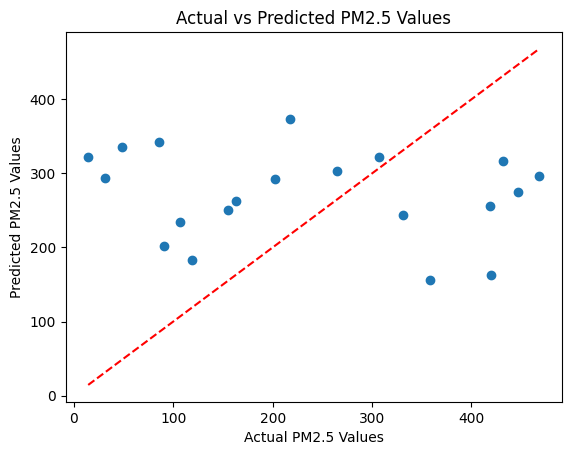

In [17]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Create a sample dataset based on the provided air quality levels
# Replace this with your actual dataset if available
data = {
    'SO2': np.random.uniform(0, 1, 100),  # Random values between 0 and 1 ppm
    'NO2': np.random.uniform(0, 2, 100),  # Random values between 0 and 2 ppm
    'CO': np.random.uniform(0, 50, 100),   # Random values between 0 and 50 ppm
    'O3': np.random.uniform(0, 0.5, 100),  # Random values between 0 and 0.5 ppm
    'PM10': np.random.uniform(0, 600, 100), # Random values between 0 and 600 µg/m³
    'PM2.5': np.random.uniform(0, 500, 100) # Random values between 0 and 500 µg/m³
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the first few rows of the dataset
print(df.head())

# Define features and target variable
X = df[['SO2', 'NO2', 'CO', 'O3', 'PM10']]  # Features
y = df['PM2.5']                             # Target variable

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Plotting the results (for visualization)
plt.scatter(y_test, y_pred)
plt.xlabel('Actual PM2.5 Values')
plt.ylabel('Predicted PM2.5 Values')
plt.title('Actual vs Predicted PM2.5 Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Diagonal line
plt.show()

Mean Squared Error: 20848.17111567871
R^2 Score: -0.0001760423998409255


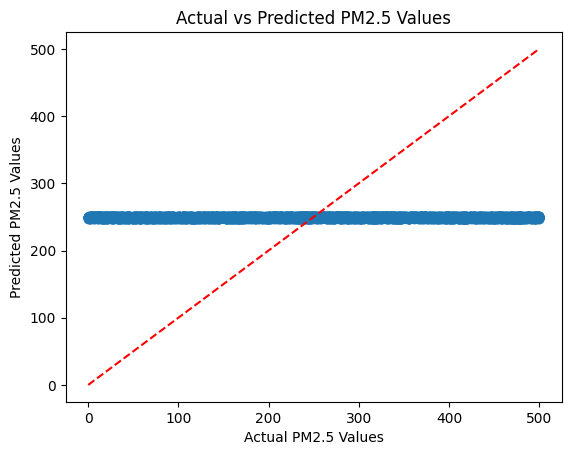

Predicted PM2.5 values for new data: [249.37427442 249.2357047 ]


In [19]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate a synthetic dataset with 110,000 instances
# Replace this with your actual dataset if available
np.random.seed(42)  # For reproducibility
data = {
    'SO2': np.random.uniform(0, 1, 110000),  # Random values between 0 and 1 ppm
    'NO2': np.random.uniform(0, 2, 110000),  # Random values between 0 and 2 ppm
    'CO': np.random.uniform(0, 50, 110000),   # Random values between 0 and 50 ppm
    'O3': np.random.uniform(0, 0.5, 110000),  # Random values between 0 and 0.5 ppm
    'PM10': np.random.uniform(0, 600, 110000), # Random values between 0 and 600 µg/m³
    'PM2.5': np.random.uniform(0, 500, 110000) # Random values between 0 and 500 µg/m³
}

# Create a DataFrame
df = pd.DataFrame(data)

# Define features and target variable
X = df[['SO2', 'NO2', 'CO', 'O3', 'PM10']]  # Features
y = df['PM2.5']                             # Target variable

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Plotting the results (for visualization)
plt.scatter(y_test, y_pred)
plt.xlabel('Actual PM2.5 Values')
plt.ylabel('Predicted PM2.5 Values')
plt.title('Actual vs Predicted PM2.5 Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Diagonal line
plt.show()

# Function to predict PM2.5 for new real-time values
def predict_pm25(new_data):
    """Predict PM2.5 levels based on new input data."""
    new_df = pd.DataFrame(new_data)
    predictions = model.predict(new_df)
    return predictions

# Example of using the prediction function with new real-time values
new_real_time_data = {
    'SO2': [0.02, 0.03],
    'NO2': [0.05, 0.06],
    'CO': [5, 10],
    'O3': [0.04, 0.05],
    'PM10': [50, 80]
}

predicted_pm25 = predict_pm25(new_real_time_data)
print(f'Predicted PM2.5 values for new data: {predicted_pm25}')

In [20]:
# Check shapes
print(f'Shape of y_test: {y_test.shape}')
print(f'Shape of y_pred: {y_pred.shape}')

# Ensure both arrays are 1D and have the same length
if y_test.shape != y_pred.shape:
    print("Error: The shapes of y_test and y_pred do not match.")
else:
    # Check for NaN or infinite values
    if np.any(np.isnan(y_test)) or np.any(np.isnan(y_pred)):
        print("Error: y_test or y_pred contains NaN values.")
    elif np.any(np.isinf(y_test)) or np.any(np.isinf(y_pred)):
        print("Error: y_test or y_pred contains infinite values.")
    else:
        # Calculate Mean Absolute Error
        mae = mean_absolute_error(y_test, y_pred)
        print(f'Mean Absolute Error (MAE): {mae:.4f}')
        # Calculate Mean Squared Error
        mse = mean_squared_error(y_test, y_pred)
        print(f'Mean Squared Error (MSE): {mse:.4f}')
        # Calculate R-squared (Coefficient of Determination)
        r_squared = r2_score(y_test, y_pred)
        print(f'R-squared (Coefficient of Determination): {r_squared:.4f}')


Shape of y_test: (22000,)
Shape of y_pred: (22000,)
Mean Absolute Error (MAE): 125.0575
Mean Squared Error (MSE): 20848.1711
R-squared (Coefficient of Determination): -0.0002
